Loaded scenarios : ['clasp_factoring', 'lpg-zeno', 'saps-CVVAR', 'spear_qcp', 'spear_swgcp', 'yalsat_qcp', 'yalsat_swgcp']


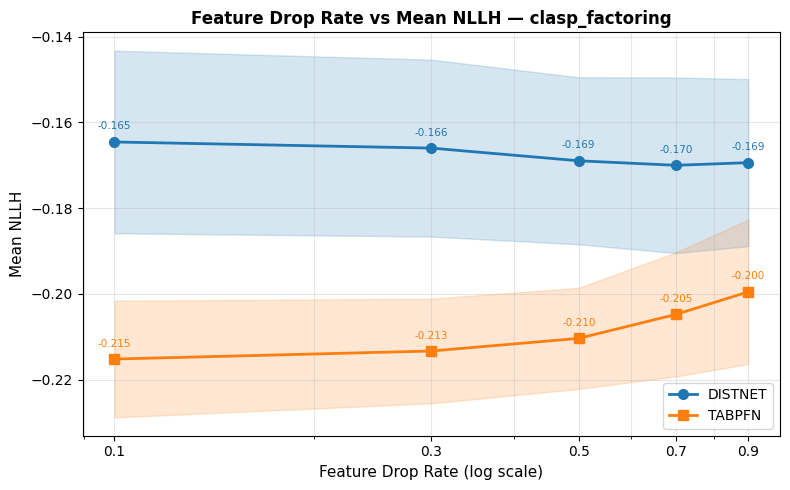


  clasp_factoring  —  Mean NLLH (mean ± std across folds)


Feature Drop Rate,0.1,0.3,0.5,0.7,0.9
Model,,,,,
distnet,-0.1646 ± 0.0213,-0.1660 ± 0.0206,-0.1690 ± 0.0195,-0.1700 ± 0.0205,-0.1694 ± 0.0195
tabpfn,-0.2152 ± 0.0136,-0.2134 ± 0.0122,-0.2104 ± 0.0118,-0.2048 ± 0.0145,-0.1995 ± 0.0168


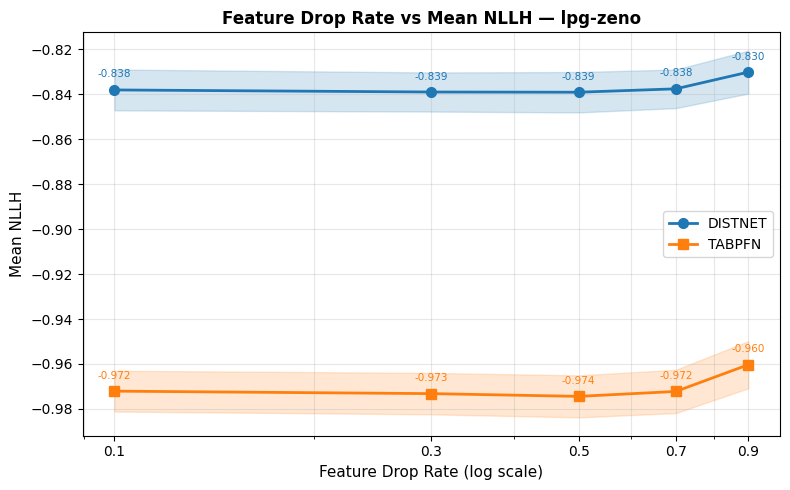


  lpg-zeno  —  Mean NLLH (mean ± std across folds)


Feature Drop Rate,0.1,0.3,0.5,0.7,0.9
Model,,,,,
distnet,-0.8381 ± 0.0091,-0.8390 ± 0.0087,-0.8391 ± 0.0090,-0.8376 ± 0.0086,-0.8302 ± 0.0095
tabpfn,-0.9721 ± 0.0091,-0.9732 ± 0.0092,-0.9744 ± 0.0093,-0.9722 ± 0.0096,-0.9603 ± 0.0105


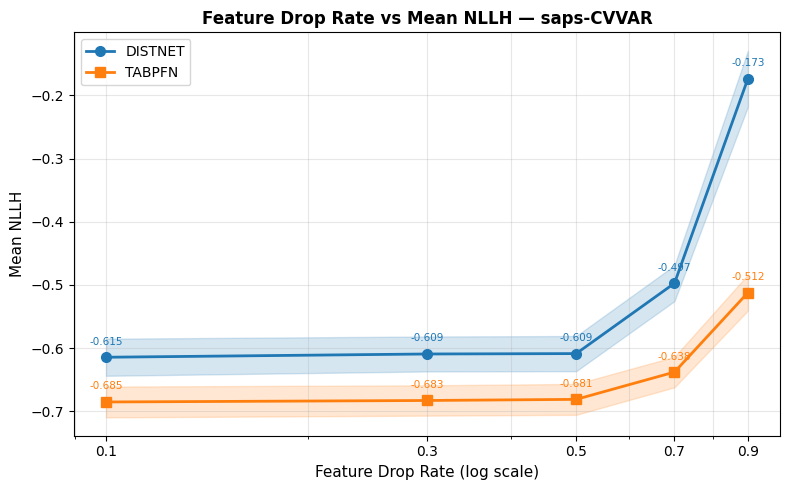


  saps-CVVAR  —  Mean NLLH (mean ± std across folds)


Feature Drop Rate,0.1,0.3,0.5,0.7,0.9
Model,,,,,
distnet,-0.6145 ± 0.0294,-0.6094 ± 0.0277,-0.6087 ± 0.0278,-0.4973 ± 0.0283,-0.1734 ± 0.0443
tabpfn,-0.6854 ± 0.0244,-0.6830 ± 0.0240,-0.6812 ± 0.0245,-0.6380 ± 0.0242,-0.5122 ± 0.0285


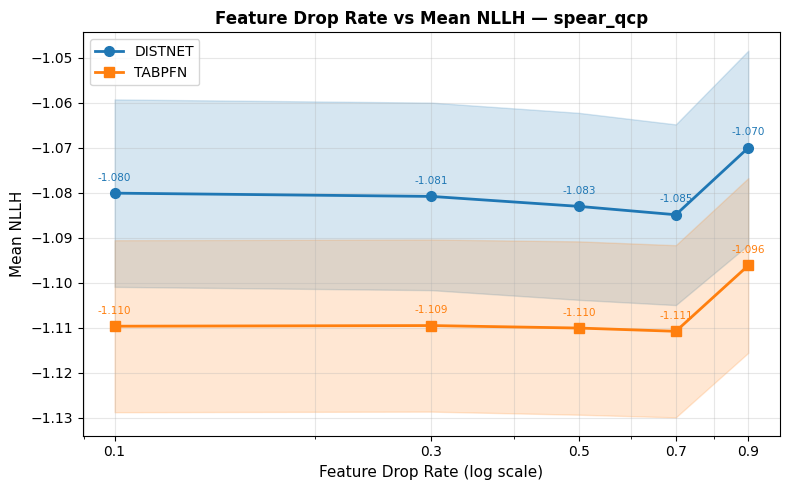


  spear_qcp  —  Mean NLLH (mean ± std across folds)


Feature Drop Rate,0.1,0.3,0.5,0.7,0.9
Model,,,,,
distnet,-1.0801 ± 0.0208,-1.0808 ± 0.0208,-1.0830 ± 0.0208,-1.0849 ± 0.0201,-1.0700 ± 0.0216
tabpfn,-1.1096 ± 0.0191,-1.1095 ± 0.0191,-1.1100 ± 0.0192,-1.1108 ± 0.0191,-1.0961 ± 0.0194


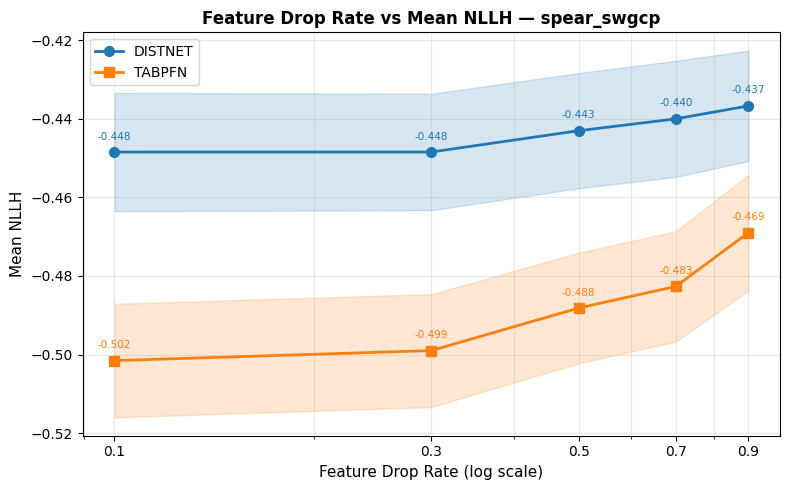


  spear_swgcp  —  Mean NLLH (mean ± std across folds)


Feature Drop Rate,0.1,0.3,0.5,0.7,0.9
Model,,,,,
distnet,-0.4485 ± 0.0150,-0.4484 ± 0.0148,-0.4430 ± 0.0147,-0.4400 ± 0.0148,-0.4367 ± 0.0141
tabpfn,-0.5015 ± 0.0145,-0.4990 ± 0.0144,-0.4882 ± 0.0141,-0.4827 ± 0.0141,-0.4690 ± 0.0147


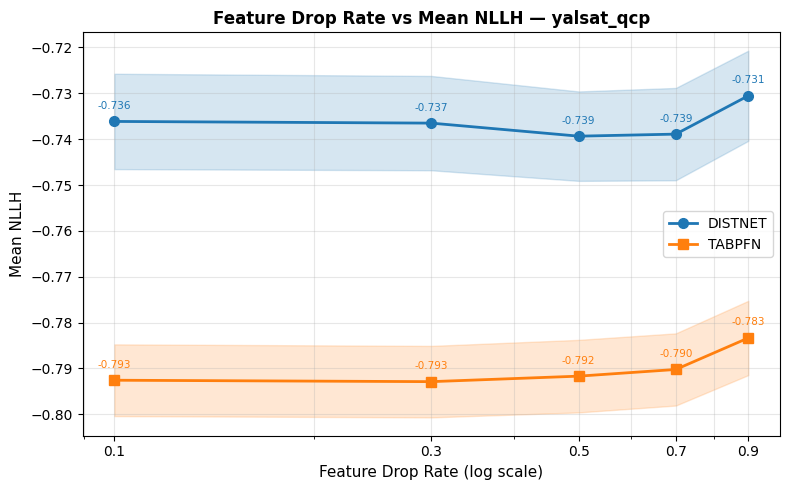


  yalsat_qcp  —  Mean NLLH (mean ± std across folds)


Feature Drop Rate,0.1,0.3,0.5,0.7,0.9
Model,,,,,
distnet,-0.7361 ± 0.0104,-0.7365 ± 0.0103,-0.7393 ± 0.0098,-0.7389 ± 0.0101,-0.7305 ± 0.0098
tabpfn,-0.7926 ± 0.0078,-0.7929 ± 0.0078,-0.7917 ± 0.0079,-0.7902 ± 0.0079,-0.7834 ± 0.0081


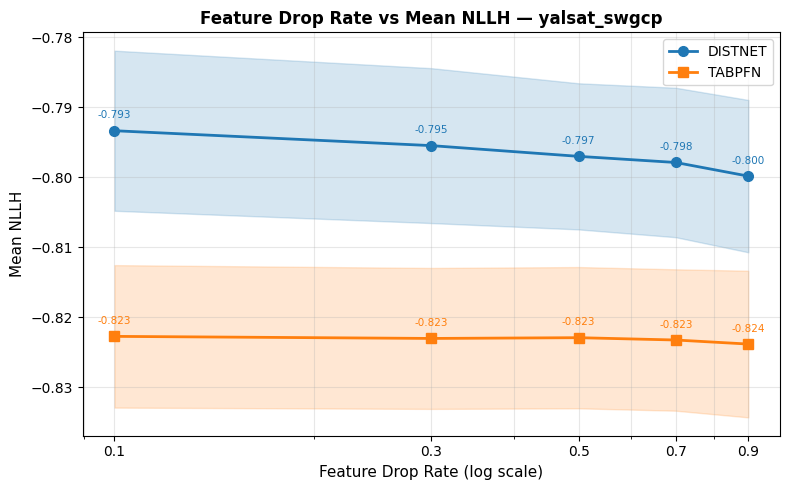


  yalsat_swgcp  —  Mean NLLH (mean ± std across folds)


Feature Drop Rate,0.1,0.3,0.5,0.7,0.9
Model,,,,,
distnet,-0.7933 ± 0.0114,-0.7955 ± 0.0111,-0.7970 ± 0.0104,-0.7979 ± 0.0107,-0.7998 ± 0.0109
tabpfn,-0.8227 ± 0.0102,-0.8230 ± 0.0101,-0.8229 ± 0.0101,-0.8232 ± 0.0101,-0.8238 ± 0.0105



✅  Global summary saved → C:\Users\ihagv\Desktop\Study Project UFR\Study_Project_Code\results\results_figures\feature_dropping\all_scenarios_summary.csv


,scenario,model,feature_drop_rate,mean_nllh,std_nllh
0,clasp_factoring,distnet,0.1,-0.164584,0.021300
1,clasp_factoring,distnet,0.3,-0.166013,0.020634
2,clasp_factoring,distnet,0.5,-0.168976,0.019484
3,clasp_factoring,distnet,0.7,-0.170027,0.020476
4,clasp_factoring,distnet,0.9,-0.169408,0.019481
...,...,...,...,...,...
65,yalsat_swgcp,tabpfn,0.1,-0.822713,0.010178
66,yalsat_swgcp,tabpfn,0.3,-0.823009,0.010068
67,yalsat_swgcp,tabpfn,0.5,-0.822902,0.010091
68,yalsat_swgcp,tabpfn,0.7,-0.823234,0.010100


In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from pathlib import Path

# ── 1. Load all .pkl files ────────────────────────────────────────────────────
metadata_dir = Path(r'C:\Users\ihagv\Desktop\Study Project UFR\Study_Project_Code\results\results_data\feature_dropping\metadata')

# Nested structure:
# data[scenario][model_name][fold][feature_drop_rate][seed_context][seed_features] = nllh
data = defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(float))))))

for pkl_file in metadata_dir.glob('*.pkl'):
    try:
        with open(pkl_file, 'rb') as f:
            d = pickle.load(f)

        model_name    = d['model_name']
        scenario      = d['scenario']
        fold          = d['fold']
        fdr           = d['feature_drop_rate']
        seed_context  = d['seed_context']
        seed_features = d['seed_features']

        # Support both key styles
        if 'result_metrics' in d:
            nllh = d['result_metrics']['nllh']
        else:
            nllh = d['metrics']['nllh']

        data[scenario][model_name][fold][fdr][seed_context][seed_features] = nllh

    except Exception as e:
        print(f"⚠️  Could not load {pkl_file.name}: {e}")

scenarios = sorted(data.keys())
models    = ['distnet', 'tabpfn']
print(f"Loaded scenarios : {scenarios}")

# ── 2. Aggregation helper ─────────────────────────────────────────────────────
def aggregate(scenario_data, model_name):
    """
    Returns {fdr: (mean_nllh, std_nllh)} where std is across folds.
    Aggregation order:
        seed_context → seed_features → fold  (mean at each level)
    """
    model_data = scenario_data.get(model_name, {})
    
    # Collect all feature drop rates
    all_fdrs = set()
    for fold_data in model_data.values():
        all_fdrs.update(fold_data.keys())
    
    result = {}
    for fdr in sorted(all_fdrs):
        fold_means = []
        for fold, fold_data in model_data.items():
            if fdr not in fold_data:
                continue
            # average over seed_context × seed_features
            vals = []
            for sc_vals in fold_data[fdr].values():       # seed_context
                for nllh in sc_vals.values():              # seed_features
                    if np.isfinite(nllh):
                        vals.append(nllh)
            if vals:
                fold_means.append(np.mean(vals))
        
        if fold_means:
            result[fdr] = (np.mean(fold_means), np.std(fold_means))
    
    return result

# ── 3. Plot + table per scenario ──────────────────────────────────────────────
MODEL_COLORS = {'distnet': '#1f77b4', 'tabpfn': '#ff7f0e'}
MODEL_MARKERS = {'distnet': 'o', 'tabpfn': 's'}

output_dir = Path(r'C:\Users\ihagv\Desktop\Study Project UFR\Study_Project_Code\results\results_figures\feature_dropping')
output_dir.mkdir(parents=True, exist_ok=True)

summary_rows = []  # for a global CSV

for scenario in scenarios:
    agg = {m: aggregate(data[scenario], m) for m in models}

    # ── collect all FDRs present for this scenario ──────────────────────────
    all_fdrs = sorted(set().union(*[set(v.keys()) for v in agg.values()]))
    if not all_fdrs:
        print(f"  No data for {scenario}, skipping.")
        continue

    # ── build table ────────────────────────────────────────────────────────
    table_rows = {}
    for model in models:
        row = {}
        for fdr in all_fdrs:
            if fdr in agg[model]:
                mean, std = agg[model][fdr]
                row[fdr] = f"{mean:.4f} ± {std:.4f}"
                summary_rows.append({'scenario': scenario, 'model': model,
                                     'feature_drop_rate': fdr,
                                     'mean_nllh': mean, 'std_nllh': std})
            else:
                row[fdr] = "N/A"
        table_rows[model] = row

    df_table = pd.DataFrame(table_rows).T
    df_table.index.name = 'Model'
    df_table.columns.name = 'Feature Drop Rate'

    # ── plot ────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 5))

    for model in models:
        if not agg[model]:
            continue
        fdrs  = np.array(sorted(agg[model].keys()), dtype=float)
        means = np.array([agg[model][f][0] for f in sorted(agg[model].keys())])
        stds  = np.array([agg[model][f][1] for f in sorted(agg[model].keys())])

        ax.plot(fdrs, means,
                marker=MODEL_MARKERS[model],
                linewidth=2, markersize=7,
                label=model.upper(),
                color=MODEL_COLORS[model])
        ax.fill_between(fdrs, means - stds, means + stds,
                        color=MODEL_COLORS[model], alpha=0.18)

        for x, y in zip(fdrs, means):
            ax.annotate(f'{y:.3f}', xy=(x, y),
                        xytext=(0, 9), textcoords='offset points',
                        ha='center', fontsize=7.5,
                        color=MODEL_COLORS[model])

    # Use symlog so that fdr=0 is also displayable; or plain log if fdr > 0 always
    if 0.0 in all_fdrs or 0 in all_fdrs:
        ax.set_xscale('symlog', linthresh=0.05)
    else:
        ax.set_xscale('log')

    ax.set_xlabel('Feature Drop Rate (log scale)', fontsize=11)
    ax.set_ylabel('Mean NLLH', fontsize=11)
    ax.set_title(f'Feature Drop Rate vs Mean NLLH — {scenario}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, which='both', alpha=0.3)
    ax.set_xticks([float(f) for f in all_fdrs])
    ax.set_xticklabels([str(f) for f in all_fdrs])

    plt.tight_layout()
    plot_path = output_dir / f'{scenario}_feature_drop_rate.png'
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

    # ── print table ────────────────────────────────────────────────────────
    print(f"\n{'='*70}")
    print(f"  {scenario}  —  Mean NLLH (mean ± std across folds)")
    print(f"{'='*70}")
    display(df_table)

    # save table as CSV
    csv_path = output_dir / f'{scenario}_results.csv'
    df_table.to_csv(csv_path)

# ── 4. Global summary CSV ─────────────────────────────────────────────────────
if summary_rows:
    df_summary = pd.DataFrame(summary_rows)
    df_summary = df_summary.sort_values(['scenario', 'model', 'feature_drop_rate'])
    summary_csv = output_dir / 'all_scenarios_summary.csv'
    df_summary.to_csv(summary_csv, index=False)
    print(f"\n✅  Global summary saved → {summary_csv}")
    display(df_summary)